In [1]:
import numpy as np
import networkx as nx

import os

from Qommunity.samplers.hierarchical.advantage_sampler import AdvantageSampler
from Qommunity.iterative_searcher import IterativeSearcher

from recover_dwave_inspector_data import recover_dwave_inspector_problems_from_runs


%load_ext autoreload
%autoreload 2

In [2]:
graphs_er = np.load("../Tutorials/ER/resolution-1/graphs-1_p-0.4.npy", allow_pickle=True)
graphs_er = [g[0] for g in graphs_er]
graphs_er_110_160 = np.load("graphs/erdos-renyi_110-160/erdos-renyi_110-160.npy", allow_pickle=True)
g_er_169 = np.load("graphs/erdos-renyi_110-160/erdos-renyi_169.npy", allow_pickle=True)
graphs_er = graphs_er + graphs_er_110_160.tolist() + g_er_169.tolist()

graphs_pwl = np.load("../Tutorials/Power-law/resolution-1/graphs-1_m-1_p-0.1.npy", allow_pickle=True)
graphs_pwl = [g[0] for g in graphs_pwl]
graphs_pwl_110_160 = np.load("graphs/powerlaw_110-160/powerlaw_graphs_110-160.npy", allow_pickle=True)
g_pwl_169 = np.load("graphs/powerlaw_110-160/powerlaw_graph_169.npy", allow_pickle=True)
graphs_pwl = graphs_pwl + graphs_pwl_110_160.tolist() + g_pwl_169.tolist()

In [3]:
results_dir_er = f"ER/resolution-1/graphs-1_p-0.4"
results_dir_pwl = f"Power-law/resolution-1/graphs-1_m-1_p-0.1"

In [4]:
from iterative_utils import IterativeSearchGraphResults
from Qommunity.searchers.utils import HierarchicalRunMetadata
from saving_utils import parse_response_json


graphs_results_er = {}

num_runs = 20
graph_sizes = [int(g.number_of_nodes()) for g in graphs_er] # 10-160 + 169


for g_size in graph_sizes:
    graphs_results_path_base = results_dir_er + f"/graph_size={g_size}/er-1_p-0.4"
    hierarchical_metadatas = []
    path = results_dir_er + f"/graph_size={g_size}"
    for iter in range(num_runs):
        base_filename = f"{path}/er_p=0.4"+f"_iter_{iter}"
        hm = HierarchicalRunMetadata.load_from_files(base_filename)
        hierarchical_metadatas.append(hm)

    path = results_dir_er + f"/graph_size={g_size}/"
    iterative_graph_results = IterativeSearchGraphResults(
        graph_ref = graphs_er[graph_sizes.index(g_size)],
        graph_size=g_size,
        communities = np.load(f"{path}/er_p=0.4_communities.npy", allow_pickle=True),
        modularities = np.load(f"{path}/er_p=0.4_modularities.npy", allow_pickle=True),
        times = np.load(f"{path}/er_p=0.4_times.npy", allow_pickle=True),
        division_modularities = np.load(f"{path}/er_p=0.4_division_modularities.npy", allow_pickle=True),
        division_trees = np.load(f"{path}/er_p=0.4_division_trees.npy", allow_pickle=True),
        hierarchical_metadatas=hierarchical_metadatas
    )

    graphs_results_er[g_size] = iterative_graph_results

In [5]:
from Qommunity.searchers.utils import HierarchicalRunMetadata

graphs_results_pwl = {}

num_runs = 20
graph_sizes = np.arange(10, 110, 10).tolist()
base = f"./{results_dir_pwl}"


for g_size in graph_sizes:
    graphs_results_path_base =  base + f"/graph_size={g_size}/powerlaw_m=1_p=0.1"
    hierarchical_metadatas = []
    
    if g_size == 150:
        for iter in range(16):
            base_filename = f"{graphs_results_path_base}_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)
        
        path = base + f"/graph_size={g_size}"
        for iter in range(3):
            base_filename = f"{path}-4runs/"+"powerlaw_m=1_p=0.1"+f"_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)
    else:
        for iter in range(num_runs):
            base_filename = f"{graphs_results_path_base}_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)

    path = base + f"/graph_size={g_size}/"
    iterative_graph_results = IterativeSearchGraphResults(
        graph_ref = graphs_pwl[graph_sizes.index(g_size)],
        graph_size=g_size,
        communities = np.load(f"{path}/powerlaw_m=1_p=0.1_communities.npy", allow_pickle=True),
        modularities = np.load(f"{path}/powerlaw_m=1_p=0.1_modularities.npy", allow_pickle=True),
        times = np.load(f"{path}/powerlaw_m=1_p=0.1_times.npy", allow_pickle=True),
        division_modularities = np.load(f"{path}/powerlaw_m=1_p=0.1_division_modularities.npy", allow_pickle=True),
        division_trees = np.load(f"{path}/powerlaw_m=1_p=0.1_division_trees.npy", allow_pickle=True),
        hierarchical_metadatas=hierarchical_metadatas
    )

    graphs_results_pwl[g_size] = iterative_graph_results

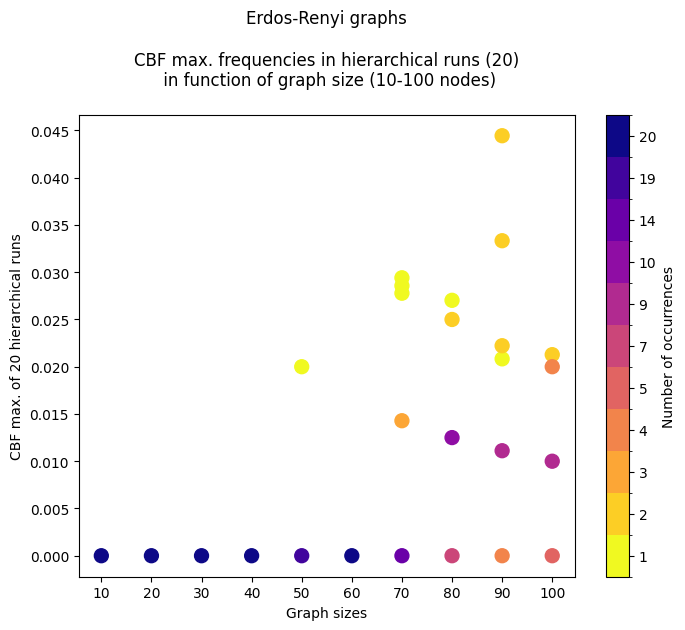

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import matplotlib.ticker as mticker
from matplotlib.colors import ListedColormap, BoundaryNorm

cbfs_maxes_per_graph_size = [graphs_results_er[g_size].cbfs_maxes for g_size in graph_sizes]
xs = [[g_size] * num_runs for g_size in graph_sizes]

all_ys = np.unique(np.concatenate(cbfs_maxes_per_graph_size))
all_x = []
all_y = []
all_counts = []

# Flatten danych i policz liczbę wystąpień
for x_row, y_row in zip(xs, cbfs_maxes_per_graph_size):
    counts = Counter(y_row)
    for y_val, count in counts.items():
        all_x.append(x_row[0])
        all_y.append(y_val)
        all_counts.append(count)

unique_counts = sorted(set(all_counts))  # uporządkowane rosnąco

# Przygotuj dyskretną paletę kolorów
cmap = ListedColormap(plt.get_cmap("plasma_r")(np.linspace(0,1,len(unique_counts))))
norm = BoundaryNorm(boundaries=np.arange(len(unique_counts)+1)-0.5, ncolors=len(unique_counts))

# Zamień liczności na indeksy kolorów
color_indices = [unique_counts.index(c) for c in all_counts]

fig, ax = plt.subplots(figsize=(8,6))

# Scatter z uporządkowanymi kolorami
scatter = ax.scatter(all_x, all_y, c=color_indices, cmap=cmap, norm=norm, s=100)

ax.set_title("Erdos-Renyi graphs\n\nCBF max. frequencies in hierarchical runs (20)\n in function of graph size (10-100 nodes)\n")
ax.set_xticks(graph_sizes)
ax.set_yticks(all_ys)
ax.set_xlabel("Graph sizes")
ax.set_ylabel("CBF max. of 20 hierarchical runs")

# Ticki całkowite na osi Y
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Dyskretny colorbar
cbar = plt.colorbar(scatter, ticks=range(len(unique_counts)))
cbar.ax.set_yticklabels(unique_counts)
cbar.set_label("Number of occurrences")

plt.show()


In [ ]:
graphs_results_er[160]

array([0.03125   , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.05      , 0.01265823, 0.        , 0.        , 0.        ,
       0.        , 0.01234568, 0.        , 0.        , 0.        ,
       0.04375   , 0.025     , 0.        , 0.02173913, 0.        ,
       0.        , 0.0125    , 0.        , 0.        , 0.        ,
       0.0375    , 0.01333333, 0.        , 0.02325581, 0.        ,
       0.        , 0.        , 0.        , 0.0625    , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.05625   , 0.01282051, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.05625   ,
       0.025     , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.04375   , 0.01219512, 0.        , 0.        ,
       0.01282051, 0.        , 0.        , 0.04375   , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

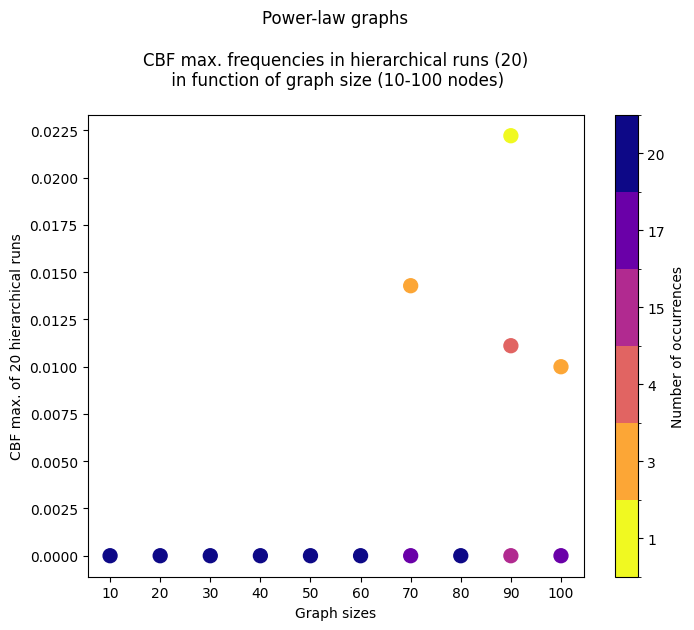

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import matplotlib.ticker as mticker
from matplotlib.colors import ListedColormap, BoundaryNorm

cbfs_maxes_per_graph_size = [graphs_results_pwl[g_size].cbfs_maxes for g_size in graph_sizes]
xs = [[g_size] * num_runs for g_size in graph_sizes]

all_ys = np.unique(np.concatenate(cbfs_maxes_per_graph_size))
all_x = []
all_y = []
all_counts = []

# Flatten danych i policz liczbę wystąpień
for x_row, y_row in zip(xs, cbfs_maxes_per_graph_size):
    counts = Counter(y_row)
    for y_val, count in counts.items():
        all_x.append(x_row[0])
        all_y.append(y_val)
        all_counts.append(count)

unique_counts = sorted(set(all_counts))  # uporządkowane rosnąco

# Przygotuj dyskretną paletę kolorów
cmap = ListedColormap(plt.get_cmap("plasma_r")(np.linspace(0,1,len(unique_counts))))
norm = BoundaryNorm(boundaries=np.arange(len(unique_counts)+1)-0.5, ncolors=len(unique_counts))

# Zamień liczności na indeksy kolorów
color_indices = [unique_counts.index(c) for c in all_counts]

fig, ax = plt.subplots(figsize=(8,6))

# Scatter z uporządkowanymi kolorami
scatter = ax.scatter(all_x, all_y, c=color_indices, cmap=cmap, norm=norm, s=100)

ax.set_title("Power-law graphs\n\nCBF max. frequencies in hierarchical runs (20)\n in function of graph size (10-100 nodes)\n")
ax.set_xticks(graph_sizes)
ax.set_yticks(all_ys)
ax.set_xlabel("Graph sizes")
ax.set_ylabel("CBF max. of 20 hierarchical runs")

# Ticki całkowite na osi Y
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Dyskretny colorbar
cbar = plt.colorbar(scatter, ticks=range(len(unique_counts)))
cbar.ax.set_yticklabels(unique_counts)
cbar.set_label("Number of occurrences")

plt.show()


In [65]:
# Power-law
hierarchical_metadata_pwl = graphs_results_pwl[100].hierarchical_metadatas
cbfs = np.empty((19, ), dtype=object)
for i in range(19):
    cbfs[i] = np.array([hm.chain_break_fraction for hm in hierarchical_metadata_pwl[i]])
modularities_pwl = graphs_results_pwl[100].modularities
communities_pwl = graphs_results_pwl[100].communities
cbfs_sums_pwl = graphs_results_pwl[100].cbfs_sum_per_run

# Erdos-Renyi
hierarchical_metadata_er = graphs_results_er[100].hierarchical_metadatas
cbfs = np.empty((20, ), dtype=object)
for i in range(20):
    cbfs[i] = np.array([hm.chain_break_fraction for hm in hierarchical_metadata_pwl[i]])
modularities_er = graphs_results_er[100].modularities
communities_er = graphs_results_er[100].communities
cbfs_sums_er = graphs_results_er[100].cbfs_sum_per_run

In [78]:
# Power-law 
mods_pwl = []
cbf_max_pwl = []
cbf_avg_pwl = []
non_zero_cbfs_pwl = []
chain_strengths_pwl = []
comms_lens_pwl = []
energies_pwl = []
indices_pwl = []

for idx, sm in enumerate(hierarchical_metadata_pwl):
    cbfs = np.array(sm.chain_break_fraction)
    non_zero_cbfs_idxs = np.where(cbfs > 0)
    cbf_max_pwl.append(cbfs.max())
    cbf_avg_pwl.append(cbfs.mean())
    non_zero_cbfs_pwl.append(cbfs[non_zero_cbfs_idxs])
    indices_pwl.append(non_zero_cbfs_idxs)

    chain_strengths_pwl.append(np.nanmean(np.array(sm.chain_strength, dtype=float)))
    mods_pwl.append(modularities_pwl[idx])
    comms_lens_pwl.append(communities_pwl[idx])


# Erdos-Renyi
mods_er = []
cbf_max_er = []
cbf_avg_er = []
non_zero_cbfs_er = []
chain_strengths_er = []
comms_lens_er = []
energies_er = []
indices_er = []

for idx, sm in enumerate(hierarchical_metadata_er):
    cbfs = np.array(sm.chain_break_fraction)
    non_zero_cbfs_idxs = np.where(cbfs > 0)
    cbf_max_er.append(cbfs.max())
    cbf_avg_er.append(cbfs.mean())
    non_zero_cbfs_er.append(cbfs[non_zero_cbfs_idxs])
    indices_er.append(non_zero_cbfs_idxs)

    chain_strengths_er.append(np.nanmean(np.array(sm.chain_strength, dtype=float)))
    mods_er.append(modularities_er[idx])
    comms_lens_er.append(communities_er[idx])

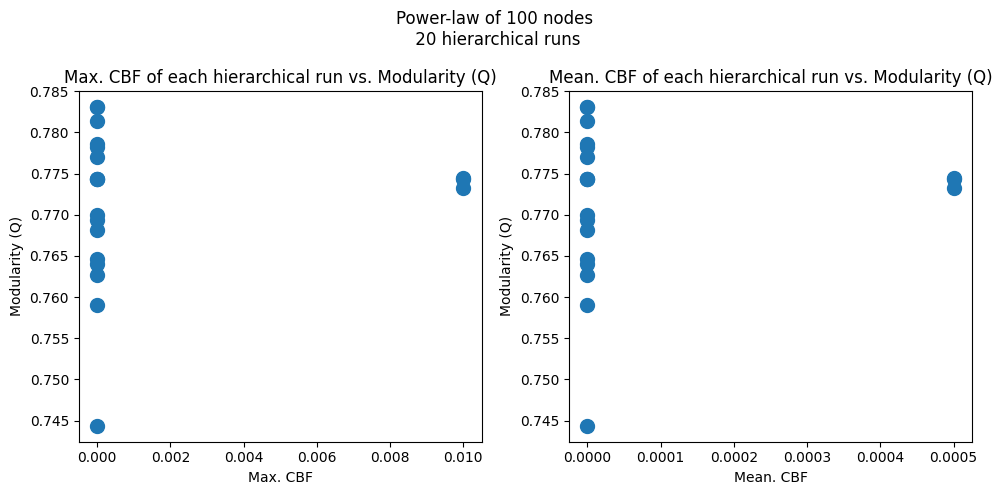

In [81]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter


fig, ax = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Power-law of 100 nodes\n 20 hierarchical runs")

ax[0].scatter(cbf_max_pwl, mods_pwl, s=100)
ax[0].set_ylabel("Modularity (Q)")
ax[0].set_xlabel("Max. CBF")
ax[0].set_title("Max. CBF of each hierarchical run vs. Modularity (Q)");

ax[1].scatter(cbf_avg_pwl, mods_pwl, s=100)
ax[1].set_ylabel("Modularity (Q)")
ax[1].set_xlabel("Mean. CBF")
ax[1].set_title("Mean. CBF of each hierarchical run vs. Modularity (Q)");

ax[1].xaxis.set_major_formatter(FormatStrFormatter('%.4f'))

plt.tight_layout()
plt.show()

# fig, ax = plt.subplots(1, 2, figsize=(10, 5))
# fig.suptitle("Powerlaw of 150 nodes\n 20 hierarchical runs")

# ax[0].scatter(cbfs_sums, mods, s=100)
# ax[0].set_ylabel("Modularity (Q)")
# ax[0].set_xlabel("Max. CBF")
# ax[0].set_title("Max. CBF of each hierarchical run vs. Modularity (Q)");

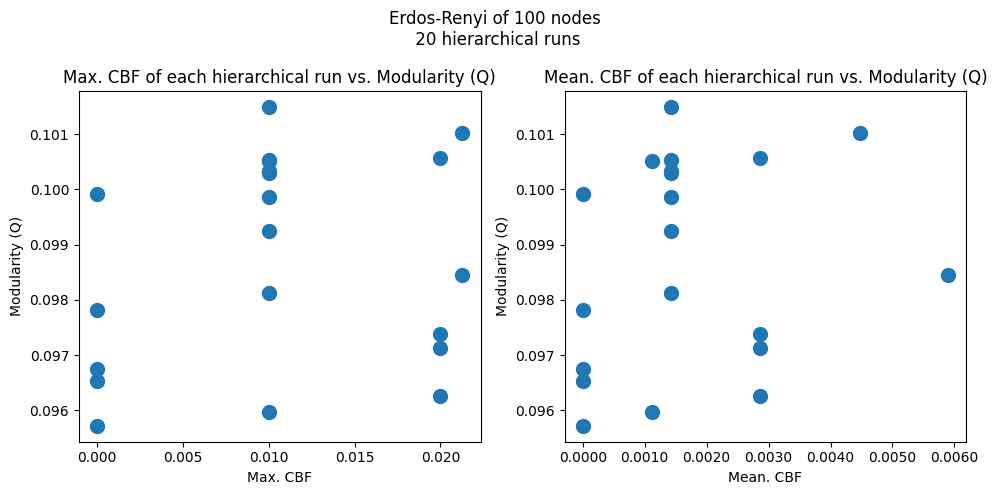

In [85]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter


fig, ax = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Erdos-Renyi of 100 nodes\n 20 hierarchical runs")

ax[0].scatter(cbf_max_er, mods_er, s=100)
ax[0].set_ylabel("Modularity (Q)")
ax[0].set_xlabel("Max. CBF")
ax[0].set_title("Max. CBF of each hierarchical run vs. Modularity (Q)");

ax[1].scatter(cbf_avg_er, mods_er, s=100)
ax[1].set_ylabel("Modularity (Q)")
ax[1].set_xlabel("Mean. CBF")
ax[1].set_title("Mean. CBF of each hierarchical run vs. Modularity (Q)");


ax[1].xaxis.set_major_formatter(FormatStrFormatter('%.4f'))

plt.tight_layout()
plt.show()

# fig, ax = plt.subplots(1, 2, figsize=(10, 5))
# fig.suptitle("Powerlaw of 150 nodes\n 20 hierarchical runs")

# ax[0].scatter(cbfs_sums, mods, s=100)
# ax[0].set_ylabel("Modularity (Q)")
# ax[0].set_xlabel("Max. CBF")
# ax[0].set_title("Max. CBF of each hierarchical run vs. Modularity (Q)");

'ER/resolution-1/graphs-1_p-0.4'

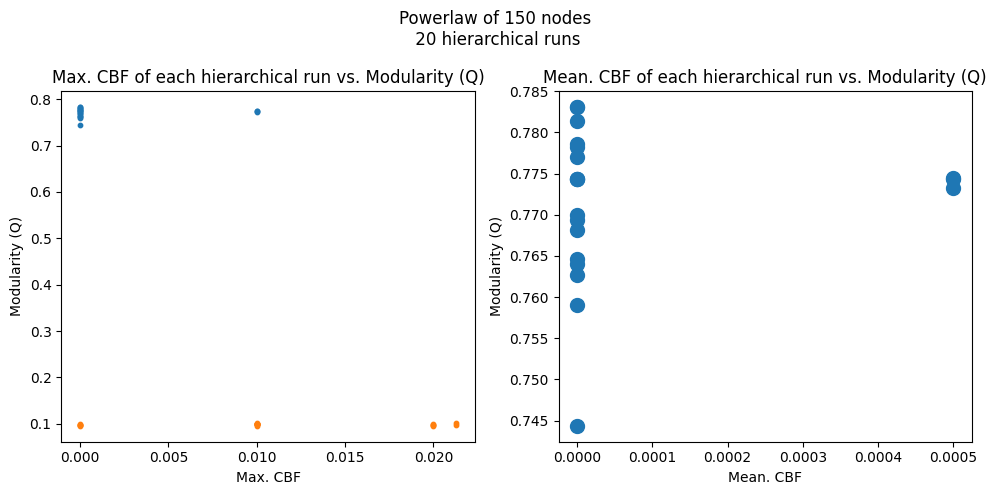

In [86]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter


fig, ax = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Powerlaw of 150 nodes\n 20 hierarchical runs")

ax[0].scatter(cbf_max_pwl, mods_pwl, s=10)
ax[0].scatter(cbf_max_er, mods_er, s=10)
ax[0].set_ylabel("Modularity (Q)")
ax[0].set_xlabel("Max. CBF")
ax[0].set_title("Max. CBF of each hierarchical run vs. Modularity (Q)");

ax[1].scatter(cbf_avg_pwl, mods_pwl, s=100)
ax[1].set_ylabel("Modularity (Q)")
ax[1].set_xlabel("Mean. CBF")
ax[1].set_title("Mean. CBF of each hierarchical run vs. Modularity (Q)");

# ax[0].set_xticks(np.unique(cbf_max))
# ax[1].set_xticks(np.unique(cbf_avg))

# ax[0].xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax[1].xaxis.set_major_formatter(FormatStrFormatter('%.4f'))
# ax[0].xaxis.set_major_formatter(FormatStrFormatter('%.2f'))

plt.tight_layout()
plt.show()

# fig, ax = plt.subplots(1, 2, figsize=(10, 5))
# fig.suptitle("Powerlaw of 150 nodes\n 20 hierarchical runs")

# ax[0].scatter(cbfs_sums, mods, s=100)
# ax[0].set_ylabel("Modularity (Q)")
# ax[0].set_xlabel("Max. CBF")
# ax[0].set_title("Max. CBF of each hierarchical run vs. Modularity (Q)");